# Time series next value prediction



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.nn import Sequential
from torch.nn import Linear
from torchinfo import summary


## Dataset generation

Let us create a function that generate a noisy sequence based on sine waves

In [4]:
def SinusGen(n,n_steps, Te=None):
    """
    This function genrates signals that are a sum of two sinus waves. Initial start time of the sine
    waves as well as their angular frequencies are chosen at random.
    Input:
    - n : the number of generated signal
    - n_steps : the size of each generated signal
    - Te : the sampling period of the signals. If not provided, Te is taken as 1/n_steps.
    Output:
    - a tuple containing the generated signals asa  2D (n x n_steps) tensor and the time axis
    """
    if Te is None:
        Te = 1/(n_steps-1)
    duration = (n_steps-1)*Te    
    time = np.linspace(0, duration, n_steps)
    omega1, omega2, delay1, delay2 = np.random.rand(4,n,1)
    delay1 *= duration
    delay2 *= duration
    signals = 0.5 * np.sin((time-delay1)*(10*omega1 + 10))
    signals += 0.2 * np.sin((time-delay2)*(20*omega2 + 20))
    signals += 0.1 * (np.random.rand(n,n_steps) - 0.5)
    return (signals.astype(np.float32),time)

Let us generate signals and sort them into train, validation and test sets.
The split between input and target for our time series prediction tasks consists in just isolating the final time sample of each signal and use it as target. The rest of the signal is used as input vector.

In [5]:
n_steps = 50
n = 10000
n_train = int(0.7*n)
n_valid = int(0.2*n)
n_test = n - n_train - n_valid
signals, time = SinusGen(n,n_steps+1)
X_train, y_train = torch.from_numpy(signals[:n_train,:n_steps]), torch.from_numpy(signals[:n_train,-1].reshape(-1,1))
X_valid, y_valid = torch.from_numpy(signals[n_train:n_train+n_valid,:n_steps]), torch.from_numpy(signals[n_train:n_train+n_valid,-1].reshape(-1,1))
X_test, y_test = torch.from_numpy(signals[n_train+n_valid:,:n_steps]), torch.from_numpy(signals[n_train+n_valid:,-1].reshape(-1,1))

Let us display one input/target pair

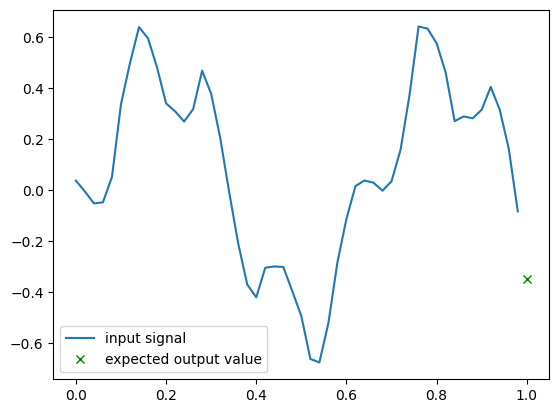

In [6]:
def display(x, y_target, time, n_steps, y_pred=None):
    plt.plot(time[:n_steps], x, label="input signal")
    if y_pred:
        plt.plot(time[n_steps], y_pred, 'o', label="output value")
    plt.plot(time[n_steps], y_target, 'x', label="expected output value", color="green")
    plt.legend()
    
ind = 0
display(X_test[ind], y_test[ind], time, n_steps)

## Torch preliminaries and Baselines

In data sciences, it is always important to compare the added value of advanced models with baseline models and gold standards. In our prediction problem, a naive approach consists in returning the last element of the input sequence as our prediction for the next value of these sequence. This "dummy" predictor appears to be not so easy to beat sometimes.

**Q1** Create a 1D numpy array `y_pred` containing predictions of the dummy predictor. The following line of code will print the MSE for this predictor.

In [7]:
from torch.nn import MSELoss

mseloss=MSELoss()

y_pred = X_test[:,-1] #Last value of inputs

print(X_test.shape)
print(y_pred.shape)
print(y_test.shape)

print("The dummy predictor MSE is", mseloss(y_pred,y_test))

torch.Size([1000, 50])
torch.Size([1000])
torch.Size([1000, 1])
The dummy predictor MSE is tensor(0.2847)


/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([1000, 1])) that is different to the input size (torch.Size([1000])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


The reported MSE of the dummy predictor is somewhat decent and we now know what level of performances we must achieve. 

Let us now create a second baseline using linear regression. The idea is simply to rely on the whole sequence and check if a linear combination of the sequence elements can produce a fair estimate of the next sequence value. .

When the architecture is linear (no branches and merges), it is very convenient to use an instance of the class `Sequential`. An object of this class is a `torch` model to which layers can be appended successively from the first one to the output one using the `add` method. 

To create a linear regression model, the most simple solution is to use a fully connected layer with only one unit in it and with a linear activation function. The `Linear` class is `torch` class for fully connected layers. 
When a layer is the first one, we need to specify the shape of the input tensor (omitting the batch dimension which has variable size). 
Let us now create this basic model using `torch`.

In [8]:
linreg = Sequential()
linreg.append(Linear(in_features=n_steps, out_features=1))

Sequential(
  (0): Linear(in_features=50, out_features=1, bias=True)
)

Torch also has a cool feature which is the `summary` method of models. This method gives an overview of the created model and helps us keep track of the number of trainable parameters.


In [9]:
summary(linreg,input_size=X_test.shape)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1000, 1]                 --
├─Linear: 1-1                            [1000, 1]                 51
Total params: 51
Trainable params: 51
Non-trainable params: 0
Total mult-adds (M): 0.05
Input size (MB): 0.20
Forward/backward pass size (MB): 0.01
Params size (MB): 0.00
Estimated Total Size (MB): 0.21

In [24]:
# Define device
device = torch.device("cpu")

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)
X_valid = X_valid.to(device)
y_valid = y_valid.to(device)

Starting from this point we can imagine a rather classical `train_procedure` as bellow.

In [25]:
def train_procedure(model, epochs, x_train, y_train, loss, optimizer, device):

    # Move model to device
    model = model.to(device)

    # Move data to device when training
    x_train = x_train.to(device)
    y_train = y_train.to(device)

    for i in range(epochs):
        model.train() #we inform that model that we switch to the training phase
        #forget about the previous gradients
        #forward the input data
        #compute the loss value
        #backpropagate the gradient
        #ask the optimizer to update the parameters
        optimizer.zero_grad()
        output=model(x_train)
        loss_value=loss(output,y_train)
        loss_value.backward()
        optimizer.step()

        print("Epoch %d loss %.4f"%(i,loss_value.item()))

In [26]:
train_procedure(linreg, 30, X_train, y_train, MSELoss(), torch.optim.Adam(linreg.parameters(),lr=0.0001), device)

Epoch 0 loss 0.1305
Epoch 1 loss 0.1302
Epoch 2 loss 0.1299
Epoch 3 loss 0.1297
Epoch 4 loss 0.1294
Epoch 5 loss 0.1291
Epoch 6 loss 0.1288
Epoch 7 loss 0.1286
Epoch 8 loss 0.1283
Epoch 9 loss 0.1280
Epoch 10 loss 0.1278
Epoch 11 loss 0.1275
Epoch 12 loss 0.1272
Epoch 13 loss 0.1270
Epoch 14 loss 0.1267
Epoch 15 loss 0.1264
Epoch 16 loss 0.1262
Epoch 17 loss 0.1259
Epoch 18 loss 0.1256
Epoch 19 loss 0.1254
Epoch 20 loss 0.1251
Epoch 21 loss 0.1249
Epoch 22 loss 0.1246
Epoch 23 loss 0.1243
Epoch 24 loss 0.1241
Epoch 25 loss 0.1238
Epoch 26 loss 0.1236
Epoch 27 loss 0.1233
Epoch 28 loss 0.1231
Epoch 29 loss 0.1228


Once the model is trained, we can evaluate the generalization capability of the model on the test set.

**Q1**
For this stage, do not forget to force torch not to compute gradients and let the model know that it should behave in evaluation mode. 

In [27]:
@torch.no_grad()
def evaluate(model, x, y, loss, device):
    model = model.to(device)
    model.eval()
    x = x.to(device)
    y = y.to(device)
    output = model(x)
    loss_value = loss(output, y)
    return loss_value
 

Test loss  tensor(0.1180)


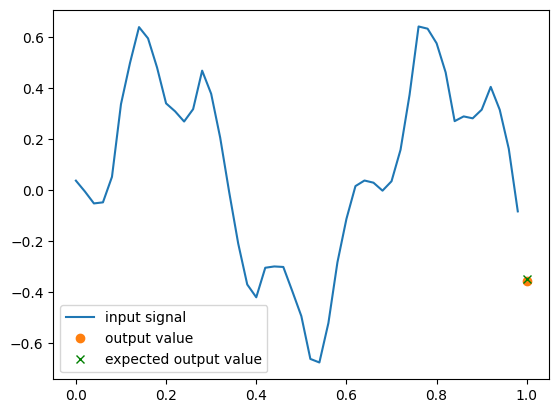

In [28]:
test_loss=evaluate(linreg,X_test,y_test,MSELoss(), device)
print("Test loss ",test_loss)

y_pred_ind = linreg(X_test[ind]).detach() # do not forget to detach() the tensor when you want to use the values as a raw array
display(X_test[ind], y_test[ind], time, n_steps, y_pred_ind)

At this point we have a running training exemple, but we need to deal both with the model construction and the training and evaluation procedures which are often the same : forget about the previous gradients, forward the input data through the model, compute the loss value, backpropagate the gradient, ask the optimizer to update the parameters, in this practical, iterate over batches/epochs, etc. 

In the following We shall explore the use of `Lightning` [framework](https://lightning.ai/docs/pytorch/stable/) that takes out the burden of manually dealing with the training steps: forward, loss computation, backward, optimized, scheduler, etc.

To do so, we will create `Lightning` [modules](https://lightning.ai/docs/pytorch/stable/common/lightning_module.html) as wrappers of our original model. The `Lightning` wrapper defines the basic building blocks for : computing the loss in varios contexts (train, validation, loss), defining the optimizer properties, etc.

The general structure of the `Lightning` module lays out as bellow. Complete the PLWrapperModel with the appropriate losses defintions.

In [37]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
import pytorch_lightning as pl

class PLWrapperModel(pl.LightningModule):
    def __init__(self, model, learning_rate=1e-3):
        super().__init__()

        self.model=model
        self.learning_rate = learning_rate
        self.train_loss = nn.MSELoss()
        self.val_loss = nn.MSELoss()
        self.test_loss = nn.MSELoss()
        self.train_losses = []
        self.val_losses = []

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.train_loss(y_hat, y)
        self.log("train_loss", loss, prog_bar=True)
        self.train_losses.append(loss.item())
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.train_loss(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)
        self.val_losses.append(loss.item())
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.test_loss(y_hat, y)
        self.log("test_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

Now that we have the `PLWrapperModel`, we need to provide the train, validation and test batches. To do so, we need to use the `DataLoader` facility. In turn, this requires from us to create a custom `Dataset`. Here bellow the code for that. 

**Q2** 
Comment each of the bellow functions.

In [30]:
class SinusDataset(Dataset):
    # Constructor of a dataset class for sinusoidal data
    def __init__(self, features, labels):
        super(SinusDataset,self).__init__()
        self.features = features
        self.labels = labels
        
    # Return the number of samples in the dataset
    def __len__(self):
        return len(self.features)
        
    # Return the sample (feature, label) corresponding to the given index
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

**Q3** Create a train, validation and test `DataLoader`s

In [34]:
batch_size=10
train_dataset = SinusDataset(X_train, y_train)
valid_dataset = SinusDataset(X_valid, y_valid)
test_dataset  = SinusDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=True)

We can now create a [`pytorch_lightning.Trainer`](https://lightning.ai/docs/pytorch/stable/common/trainer.html) by specific the maximum number of epochs.

In [38]:
trainer = Trainer(max_epochs=5)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training a model comes now to : wrap the model, call the fit method on the trainer.

In [39]:
linreg = Sequential()
linreg.append(Linear(in_features=n_steps, out_features=1))

wrapper=PLWrapperModel(linreg)

trainer.fit(wrapper, train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model      | Sequential | 51     | train | 0    
1 | train_loss | MSELoss    | 0      | train | 0    
2 | val_loss   | MSELoss    | 0      | train | 0    
3 | test_loss  | MSELoss    | 0      | train | 0    
----------------------------------------------------------
51        Trainable params
0         Non-trainable params
51        Total params
0.000     Total estimated model params size (MB)
5        

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Let us now evaluate the trained model on the test set. Call the `test` function of your `trainer` and provide it with the already created `test_loader`.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.0038070054724812508
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


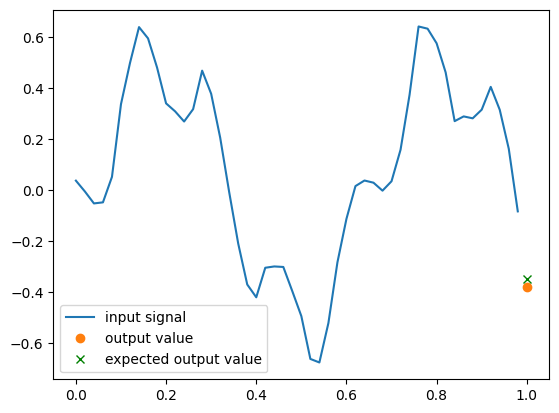

In [40]:
test_loss=trainer.test(wrapper,test_loader)

y_pred_ind = wrapper.model(X_test[ind]).detach()
display(X_test[ind], y_test[ind,0], time, n_steps, y_pred_ind)

We see that the reported MSE for linear regression is much better than the dummy predictor MSE. 

The `display` function shows a sequence of the test set and the predicted next value. Predicted outputs can be obtained from the model that is wrapped by invoking the `__call__` method which just need to fed with a tensor of test vectors.

Before moving to more advanced models, let us set up the early stopping procedure as this will avoid excessive traning time. We will measure the loss after each epoch. For that we will enhance the trainer with an `EarlyStopping` `callback` that measure the evolution of the one of the training outputs (`loss`, `accuracy`, etc.)

In [41]:
# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=True,
    mode='min',
    min_delta=1e-4 #we except an improvement of at least 1e-4 between iterations
)

# Use it with the trainer
trainer = Trainer(
    max_epochs=100,
    callbacks=[early_stopping]
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Redo the training and evaluate again the model. We now need to provide both trainer_loader and valid_loader for the training phase (`fit` call).

In [42]:
linreg = Sequential()
linreg.append(Linear(in_features=n_steps, out_features=1))

wrapper=PLWrapperModel(linreg)

trainer.fit(wrapper, train_loader, valid_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model      | Sequential | 51     | train | 0    
1 | train_loss | MSELoss    | 0      | train | 0    
2 | val_loss   | MSELoss    | 0      | train | 0    
3 | test_loss  | MSELoss    | 0      | train | 0    
----------------------------------------------------------
51        Trainable params
0         Non-trainable params
51        Total params
0.000     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.003. Signaling Trainer to stop.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.0031530156265944242
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


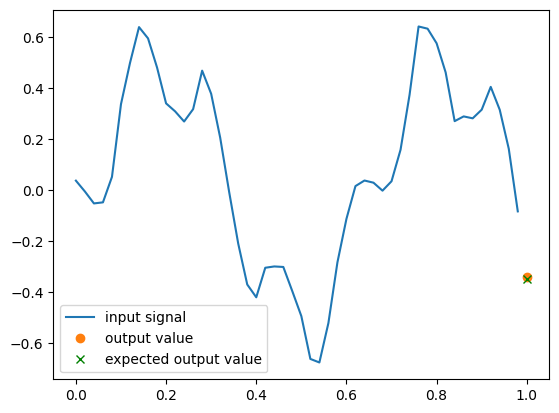

In [43]:
test_loss = trainer.test(wrapper,test_loader)

y_pred_ind = wrapper.model(X_test[ind]).detach()

display(X_test[ind], y_test[ind], time, n_steps, y_pred_ind)

Early stopping allowed to end the training loop a lot sooner than the prescribed number of epochs. It returns the model achieving minimal validation loss across epochs. The reported performances might be slightly better than without early stopping but given that linear regression is a very simple model those performance differences are not really meaningful.

Finally, `Lightning` also allows to plot the evoluation of the loss across epochs using the history constructed while calling the `fit` method, which in turn calls `training_step` and `validation_step`.

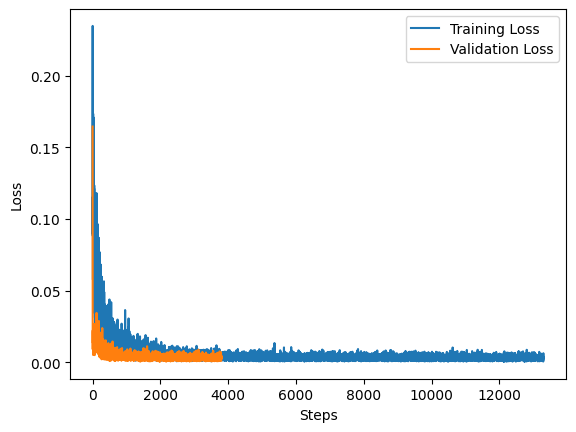

In [44]:
plt.plot(wrapper.train_losses, label="Training Loss")
plt.plot(wrapper.val_losses, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Q4** Design a one-hidden-layer `MLP` using torch and see if you can beat linear regression (you should).

In [51]:
mlp = Sequential()
hidden_size = 10
mlp.append(torch.nn.Linear(in_features=n_steps,out_features=hidden_size))
mlp.append(nn.ReLU())
mlp.append(torch.nn.Linear(in_features=hidden_size,out_features=1))

Sequential(
  (0): Linear(in_features=50, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
)

**Q5** Wrap the model and proceed with training using at maximum 1000 epochs and a patience of 5 for an early stoping mechanism based on the `loss` metric.

In [52]:
wrapper_mlp = PLWrapperModel(mlp)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=True,
    mode='min',
    min_delta=1e-4 #we except an improvement of at least 1e-4 between iterations
)

trainer = Trainer(
    max_epochs=1000,
    callbacks=[early_stopping],
)

trainer.fit(wrapper_mlp, train_loader, valid_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model      | Sequential | 521    | train | 0    
1 | train_loss | MSELoss    | 0      | train | 0    
2 | val_loss   | MSELoss    | 0      | train | 0    
3 | test_loss  | MSELoss    | 0      | train | 0    
----------------------------------------------------------
521       Trainable params
0         Non-trainable params
5

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 5 records. Best score: 0.003. Signaling Trainer to stop.


**Q6** Evaluate the model (as in the previous questions) and discuss.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.0030279827769845724
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


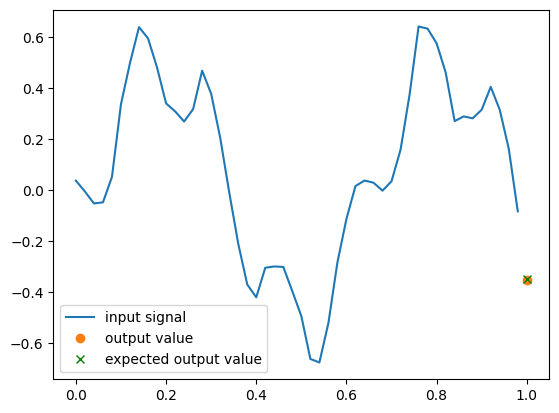

In [53]:
test_loss = trainer.test(wrapper_mlp,test_loader)

y_pred_ind = wrapper_mlp.model(X_test[ind]).detach()

display(X_test[ind], y_test[ind], time, n_steps, y_pred_ind)

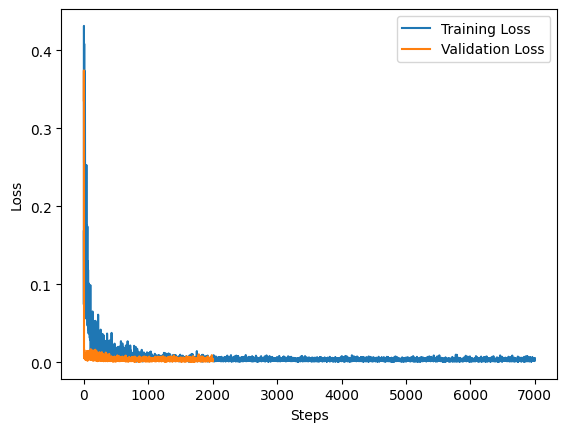

In [54]:
plt.plot(wrapper_mlp.train_losses, label="Training Loss")
plt.plot(wrapper_mlp.val_losses, label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Simple RNNs

Because the input sequences in our dataset rely on the sine function, they exhibit quasi-periodicity. We can therefore be confident that a form of recursion somewhat governs the unknown mapping from inputs to targets. Recurrent neural networks (RNNs) should thus be able to learn this recursive pattern.

We shall start with the most simple form of RNNs. There is a torch class  called [`RNN`](https://docs.pytorch.org/docs/stable/generated/torch.nn.RNN.html) that encodes this notion. There is only one slight difficulty in using it as compared to fully connected layers from the `Linear` class: the expected `input_shape` parameter is a list of two integers:
* the 1st integer concerns the sequence length.
* the 2nd integer, it specifies the dimensionality of members of the sequence (in our case 1). 
Similarly as for `Linear` layers the dimensions of mini-batches is omitted.

In our setting, the tensor that we will later give to the `fit` method has shape `(.., n_steps)`. This does not match the information we gave to `RNN` and we must therefore reshape this tensor to `(.., n_steps, 1)`. This can be done with `numpy` but in `torch` we can create a custom layer that we call `ReshapeForRNN` and which take this in charge. 

Check the following code which is an implementation of a simple RNN for our data.

**Q7** Comment the `forward` function.


In [61]:
from torch.nn import RNN

class ReshapeForRNN(nn.Module):
    def __init__(self, sequence_length, input_size):
        super().__init__()
        self.sequence_length = sequence_length
        self.input_size = input_size
        
    # Reshape the input tensor to have the shape (batch_size, sequence_length, input_size)
    def forward(self, x):
        return x.view(-1, self.sequence_length, self.input_size)

input_dim=1
hidden_dim=1
n_steps=50

simpleRNN = Sequential()
simpleRNN.append(ReshapeForRNN(n_steps,input_dim))
simpleRNN.append(RNN(input_dim,hidden_dim,num_layers=1,batch_first=False))

output,hn=simpleRNN(X_train)
print(output.shape, hn.shape)
print((output[-1]-hn).min().detach(),(output[-1]-hn).max().detach())

torch.Size([7000, 50, 1]) torch.Size([1, 50, 1])
tensor(0.) tensor(0.)


One can observe that output of the RNN layer is composed of :
* the outputs for each input sample `output` (output.shape[0] == total size) and for each step (output.shape[1] == n_steps);
* the hidden state of the last step `hn`

In the case where we only use one layer (`layer==1`) then `output[-1] == hn`

Now, if we want to compute the `loss` from the last output, we would need to add a new custom layer `KeepOnlyLastTimeStepFromRNN` that only keeps the information of the last time step for each sample, in order to be able to compare it to the target.

**Q8** Comment the `forward` function in `KeepOnlyLastTimeStepFromRNN`

In [66]:
from torch.nn import RNN

class ReshapeForRNN(nn.Module):
    def __init__(self, sequence_length, input_size):
        super().__init__()
        self.sequence_length = sequence_length
        self.input_size = input_size

    def forward(self, x):
        return x.view(-1, self.sequence_length, self.input_size)
        
class KeepOnlyLastTimeStepFromRNN(nn.Module):
    def __init__(self):
        super().__init__()

    # Keep only the output of the last time step from the RNN output
    def forward(self, x):
        output,hn=x
        return output[:,-1,:]

simpleRNN = Sequential()
simpleRNN.append(ReshapeForRNN(n_steps,input_dim))
output=simpleRNN(X_train)
print(output.shape)

simpleRNN.append(RNN(input_dim,hidden_dim,num_layers=1,batch_first=False))
output=simpleRNN(X_train)
#print(output.shape)

simpleRNN.append(KeepOnlyLastTimeStepFromRNN())
output=simpleRNN(X_train)
print(output.shape)

torch.Size([7000, 50, 1])
torch.Size([7000, 1])


You can ofcours drop the intermedia output computations. They were added just to inform you about the shapes of the intermediate ouputs.

We now have a `simpleRNN` model that can be trained.

In [67]:
# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    verbose=True,
    mode='min',
    min_delta=1e-4
)

# Use it with the trainer
trainer = Trainer(
    max_epochs=100,
    callbacks=[early_stopping]
)

wrapper=PLWrapperModel(simpleRNN)
trainer.fit(wrapper, train_loader, valid_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model      | Sequential | 4      | train | 0    
1 | train_loss | MSELoss    | 0      | train | 0    
2 | val_loss   | MSELoss    | 0      | train | 0    
3 | test_loss  | MSELoss    | 0      | train | 0    
----------------------------------------------------------
4         Trainable params
0         Non-trainable params
4

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.020


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 2 records. Best score: 0.020. Signaling Trainer to stop.


**Q9** Evaluate the model and compare it to the previous results.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:485: Your `test_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/mnt/c/Users/maner/OneDrive/Documents/centrale/ML3/RNN/ml_venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.019205139949917793
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


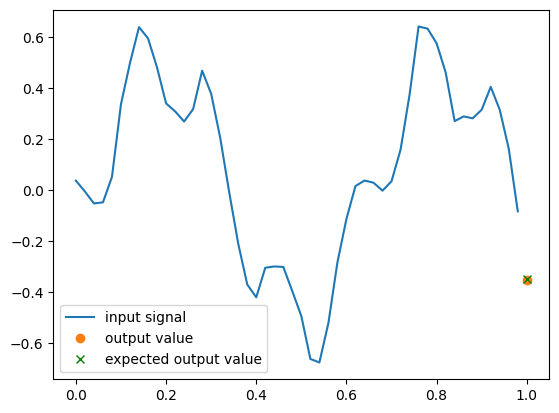

In [68]:
test_loss = trainer.test(wrapper,test_loader)

y_pred_ind = wrapper_mlp.model(X_test[ind]).detach()

display(X_test[ind], y_test[ind], time, n_steps, y_pred_ind)

**Q10** You can change the learning rate to 0.005 to speed up the exploration. Re-evaluate the model. Comment


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type       | Params | Mode  | FLOPs
----------------------------------------------------------
0 | model      | Sequential | 4      | train | 0    
1 | train_loss | MSELoss    | 0      | train | 0    
2 | val_loss   | MSELoss    | 0      | train | 0    
3 | test_loss  | MSELoss    | 0      | train | 0    
----------------------------------------------------------
4         Trainable params
0         Non-trainable params
4

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.021


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 2 records. Best score: 0.020. Signaling Trainer to stop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.019217565655708313
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


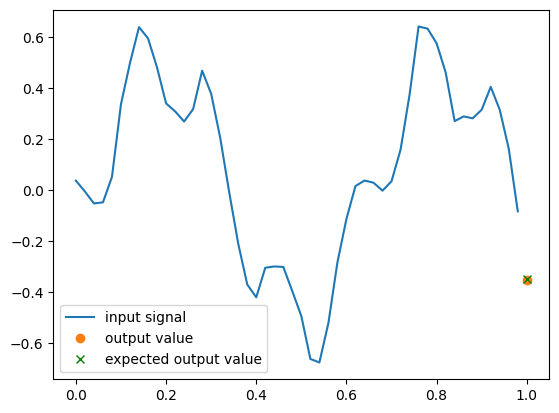

In [71]:
# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    verbose=True,
    mode='min',
    min_delta=1e-4
)

# Use it with the trainer
trainer = Trainer(
    max_epochs=100,
    callbacks=[early_stopping]
)

wrapper=PLWrapperModel(simpleRNN, learning_rate=0.005)
trainer.fit(wrapper, train_loader, valid_loader)

test_loss = trainer.test(wrapper,test_loader)

y_pred_ind = wrapper_mlp.model(X_test[ind]).detach()

display(X_test[ind], y_test[ind], time, n_steps, y_pred_ind)

The results are a bit better than the dummy predictor! But observe that it trains only four parameters so there is definitely room for improvement.

**Q11** Design a deeper (multi-layer) simple RNN and try to improve the MSE while using no more than 100 parameters.

To plug RNN layers together, you have choose between many-to-one or many-to-many layers as the unrolled networks will be very different ! By default, Torch `RNN` class uses a many-to-many configuration. To switch to a many-to-one, we have employed the custom `KeepOnlyLastTimeStepFromRNN` layer previously.

Now if we want to bridge all the intermediate step values to an MLP (`Linear`), we should converse all outputs and drop the `hn` from the regular `torch.nn.RNN` class. For that we designed `KeepAllTimeStepOutputsFromRNN`

In [ ]:
from torch.nn import RNN

class ReshapeForRNN(nn.Module):
    def __init__(self, sequence_length, input_size):
        super().__init__()
        self.sequence_length = sequence_length
        self.input_size = input_size

    def forward(self, x):
        return x.view(-1, self.sequence_length, self.input_size)
        
class KeepAllTimeStepOutputsFromRNN(nn.Module):
    def __init__(self,n_steps,hidden_dim):
        super().__init__()
        self.n_steps=n_steps
        self.hidden_dim=hidden_dim
        
    # reshape the output of the RNN as (batch_size, n_steps, hidden_dim)
    def forward(self, x):
        output,hn=x
        return output.view(-1,self.n_steps,self.hidden_dim)

class FlattenTimeStepOutputsFromRNN(nn.Module):
    def __init__(self,n_steps,hidden_dim):
        super().__init__()
        self.n_steps=n_steps
        self.hidden_dim=hidden_dim
        
    # Flatten the output of the RNN to have the shape (batch_size, n_steps*hidden_dim)
    def forward(self, x):
        return x.view(-1,self.n_steps*self.hidden_dim)

n_steps=50
input_dim=1
hidden_dim=1

rnn = Sequential()
rnn.append(ReshapeForRNN(n_steps,input_dim))
output=rnn(X_train)
print(output.shape)

rnn.append(RNN(input_dim,hidden_dim,num_layers=1,batch_first=False))
output,_=rnn(X_train)
print(output.shape)

rnn.append(KeepAllTimeStepOutputsFromRNN(n_steps=n_steps,hidden_dim=hidden_dim))
output=rnn(X_train)
print(output.shape)

rnn.append(FlattenTimeStepOutputsFromRNN(n_steps=n_steps,hidden_dim=hidden_dim))
output=rnn(X_train)
print(output.shape)

rnn.append(Linear(in_features=n_steps*hidden_dim,out_features=1))
output=rnn(X_train)
print(output.shape)

**Q12** Train, evaluate, comment

The performances should be roughly the same as linear regression but better than the single layer RNN.

# RNNs and MLPs combined

In the last model you devised, the last simple RNN layer is not so useful because it necessarily has only one neural unit as the size of the hidden state must match the size of targets (i.e. 1). So it presumably just carries over from time step to time step relevant computations coming from the previous layers.

A more satisfying solution would be to plug a simple RNN layer (with a larger hidden state size) into an MLP. This can be easily done by using a many-to-one configuration for the last simple RNN layer of the architecture.

**Q13** Design a multi-layer simple RNN architecture plugged into a fully connected layer and try to obtain similar performances as before. 

In [ ]:
input_dim=1
hidden_dim=5

rnn = Sequential()

rnn.append(ReshapeForRNN(n_steps,input_dim))

#We keep all time step outputs for feeding them in a many-to-many way to the next layer
rnn.append(RNN(input_dim,hidden_dim,num_layers=1,batch_first=False))
rnn.append(KeepAllTimeStepOutputsFromRNN(...,...))
output=rnn(X_train)
print(output.shape)

#We keep all time step outputs from Layer 1 and feed them into the 2nd layer
#Here we keep the same number of hidden_dim, so input_dim and hidden_dim on this 2nd layer are the same
rnn.append(RNN(...,...,num_layers=1,batch_first=False))
rnn.append(KeepAllTimeStepOutputsFromRNN(...,...))
output=rnn(X_train)
print(output.shape)

#We keep all time step outputs from Layer 2 and feed them into the 3nd layer
#Here we prepare the 3rd layer to be connected directly to an MLP, so we reduce number of hidden_dim to 1
rnn.append(RNN(...,1,num_layers=1,batch_first=False))
output,_=rnn(X_train)
print(output.shape)

rnn.append(KeepAllTimeStepOutputsFromRNN(...,...))
output=rnn(X_train)
print(output.shape)

#We need now to flatten the times steps in order to feed the Linear layer
rnn.append(FlattenTimeStepOutputsFromRNN(...,...))
output=rnn(X_train)
print(output.shape)

rnn.append(Linear(in_features=...,out_features=...))
output=rnn(X_train)
print(output.shape)

**Q14** Train, evaluate, comment

# Predicting the next 10 values

In most time series prediction tasks, one is not only interested in the very next value of a sequence but also in values in a horizon of, say 10, next values. Let us check if some of the above architectures can learn to do that efficiently.

Coupled with this idea, it appears that we haven't fully exploited our data because we could ask RNNs to "perpetually" make predictions, i.e. not only predict when the input sequence is over. This may help us learning a better model because we will be in a many-to-many configuration and gradients will flow more efficienlty.

Let us first prepare the dataset of this new (and more difficult) task.

In [7]:
horizon = 10
signals, time = SinusGen(n,n_steps+horizon)
X_train = signals[:n_train,:n_steps]
X_valid = signals[n_train:n_train+n_valid,:n_steps]
X_test= signals[n_train+n_valid:,:n_steps]

(7000, 50) (7000, 50, 10)


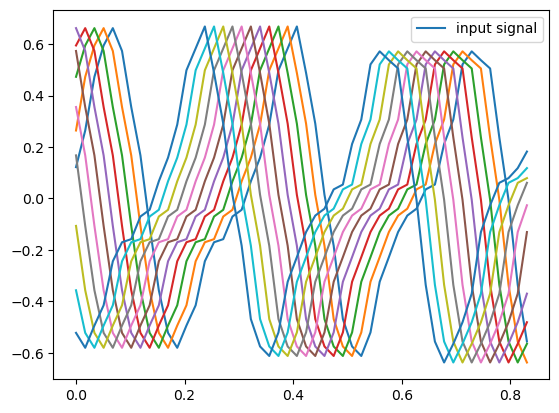

In [8]:
Y = np.empty((10000, n_steps, horizon))
for step_ahead in range(1, horizon + 1):
    Y[..., step_ahead - 1] = signals[..., step_ahead:step_ahead + n_steps]
y_train = Y[:7000]
y_valid = Y[7000:9000]
y_test = Y[9000:]
print(X_train.shape, y_train.shape)
plt.plot(time[:n_steps], X_test[ind], label="input signal")
for i in range(horizon):
    plt.plot(time[:n_steps], y_test[ind,:,i],)
plt.legend()

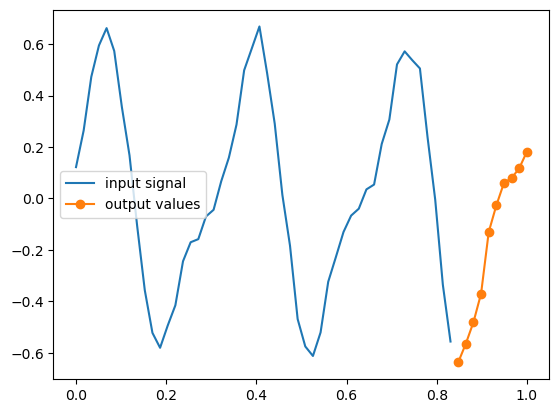

In [9]:
def display2(x, y, time, n_steps, horizon):
    plt.plot(time[:n_steps], x, label="input signal")
    plt.plot(time[n_steps:n_steps+horizon], y[-1,:], '-o', label="output values")
    plt.legend()
    
ind = 0
display2(X_test[ind], y_test[ind], time, n_steps, horizon)

**Q15** Create a multi-layer simple RNN architecture and fit it to this new dataset.

**Q16** Train, evaluate, comment.

**Q17** Overall conclusion